# Q1 — Estimate Error: Circular Distance and Time-Course Stability

**Question:** Calculate the circular distance between displayed motion direction and subject estimate (estimate error) at each trial. Plot the errors time course. Are errors stable over trials? If not, why not?

**Dataset:** Laquitaine & Gardner (2017) — `data01_direction4priors.csv`, same source as the NMA loader notebook.

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, mannwhitneyu

plt.rcParams["figure.figsize"] = [10, 4]
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG = np.random.default_rng(42)

## 1. Load the dataset

In [2]:
DATA_URL = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data01_direction4priors.csv")

if not os.path.exists(DATA_PATH):
    r = requests.get(DATA_URL, timeout=30)
    r.raise_for_status()
    with open(DATA_PATH, "wb") as f:
        f.write(r.content)

data = pd.read_csv(DATA_PATH)
data.head()

,trial_index,trial_time,response_arrow_start_angle,motion_direction,motion_coherence,estimate_x,estimate_y,reaction_time,raw_response_time,prior_std,prior_mean,subject_id,experiment_name,experiment_id,session_id,run_id
0,1,0.000000,NaN,225,0.12,-1.749685,-1.785666,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
1,2,2.730730,NaN,225,0.12,-1.819693,-1.714269,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
2,3,4.913950,NaN,235,0.06,-1.562674,-1.951422,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
3,4,6.997296,NaN,225,0.06,-1.601388,-1.919781,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
4,5,9.097130,NaN,215,0.24,-1.639461,-1.887371,NaN,NaN,10,225,1,data01_direction4priors,11,1,1


## 2. Compute circular estimate error

The estimate angle is recovered from the (x, y) response coordinates via `arctan2`. The circular (signed) error is the shortest angular difference between the estimate and the true motion direction, wrapped to $(-180, 180]$ degrees.

In [3]:
def wrap_deg(x):
    """wrap angle in degrees to [0, 360)"""
    return np.mod(x, 360)


def circ_diff_deg(a, b):
    """shortest signed circular difference a - b, in degrees, range (-180, 180]"""
    return np.mod(np.asarray(a) - np.asarray(b) + 180, 360) - 180


data["estimate_angle"] = wrap_deg(np.degrees(np.arctan2(data["estimate_y"], data["estimate_x"])))
data["error_deg"] = circ_diff_deg(data["estimate_angle"], data["motion_direction"])
data["abs_error_deg"] = np.abs(data["error_deg"])

# drop trials with no valid estimate
data = data.dropna(subset=["estimate_angle", "motion_direction", "prior_std", "prior_mean", "motion_coherence"]).reset_index(drop=True)

print(f"N trials after cleaning: {len(data)}")
print(f"N subjects: {data['subject_id'].nunique()}")
print(f"Prior std values: {sorted(data['prior_std'].unique())}")
print(f"Prior mean values: {sorted(data['prior_mean'].unique())}")
print(f"Motion coherence values: {sorted(data['motion_coherence'].unique())}")
data[["trial_index", "subject_id", "motion_direction", "estimate_angle", "error_deg", "abs_error_deg", "prior_std", "prior_mean", "motion_coherence"]].head(10)

N trials after cleaning: 83210
N subjects: 12
Prior std values: [np.int64(10), np.int64(20), np.int64(40), np.int64(80)]
Prior mean values: [np.int64(225)]
Motion coherence values: [np.float64(0.06), np.float64(0.12), np.float64(0.24)]


,trial_index,subject_id,motion_direction,estimate_angle,error_deg,abs_error_deg,prior_std,prior_mean,motion_coherence
0,1,1,225,225.583113,0.583113,0.583113,10,225,0.12
1,2,1,225,223.291282,-1.708718,1.708718,10,225,0.12
2,3,1,235,231.312691,-3.687309,3.687309,10,225,0.06
3,4,1,225,230.166776,5.166776,5.166776,10,225,0.06
4,5,1,215,229.020860,14.020860,14.020860,10,225,0.24
5,6,1,205,223.291282,18.291282,18.291282,10,225,0.24
6,7,1,235,226.729029,-8.270971,8.270971,10,225,0.06
7,8,1,215,219.853535,4.853535,4.853535,10,225,0.12
8,9,1,225,230.166776,5.166776,5.166776,10,225,0.12
9,10,1,225,235.896354,10.896354,10.896354,10,225,0.12


## 3. Plot the error time course

### 3a. Overall time course (all subjects pooled, coloured by prior_std)

Trials are sorted chronologically within each subject. `prior_std` is organized in long blocks within each session, while `motion_coherence` varies trial-by-trial.

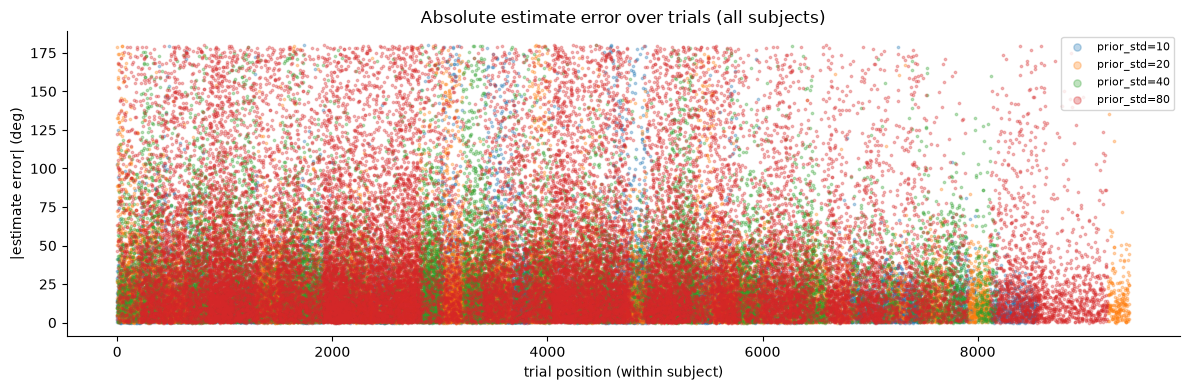

In [4]:
data_sorted = data.sort_values(["subject_id", "session_id", "run_id", "trial_index"]).reset_index(drop=True)
data_sorted["global_trial"] = data_sorted.groupby("subject_id").cumcount()

fig, ax = plt.subplots(figsize=(12, 4))
for ps, sub in data_sorted.groupby("prior_std"):
    ax.scatter(sub["global_trial"], sub["abs_error_deg"], s=3, alpha=0.3, label=f"prior_std={ps}")
ax.set_xlabel("trial position (within subject)")
ax.set_ylabel("|estimate error| (deg)")
ax.set_title("Absolute estimate error over trials (all subjects)")
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

### 3b. Per-subject time course (first 6 subjects)

Each subject's error trace. Vertical dotted lines mark changes in `prior_std` (which happens infrequently — long blocks).

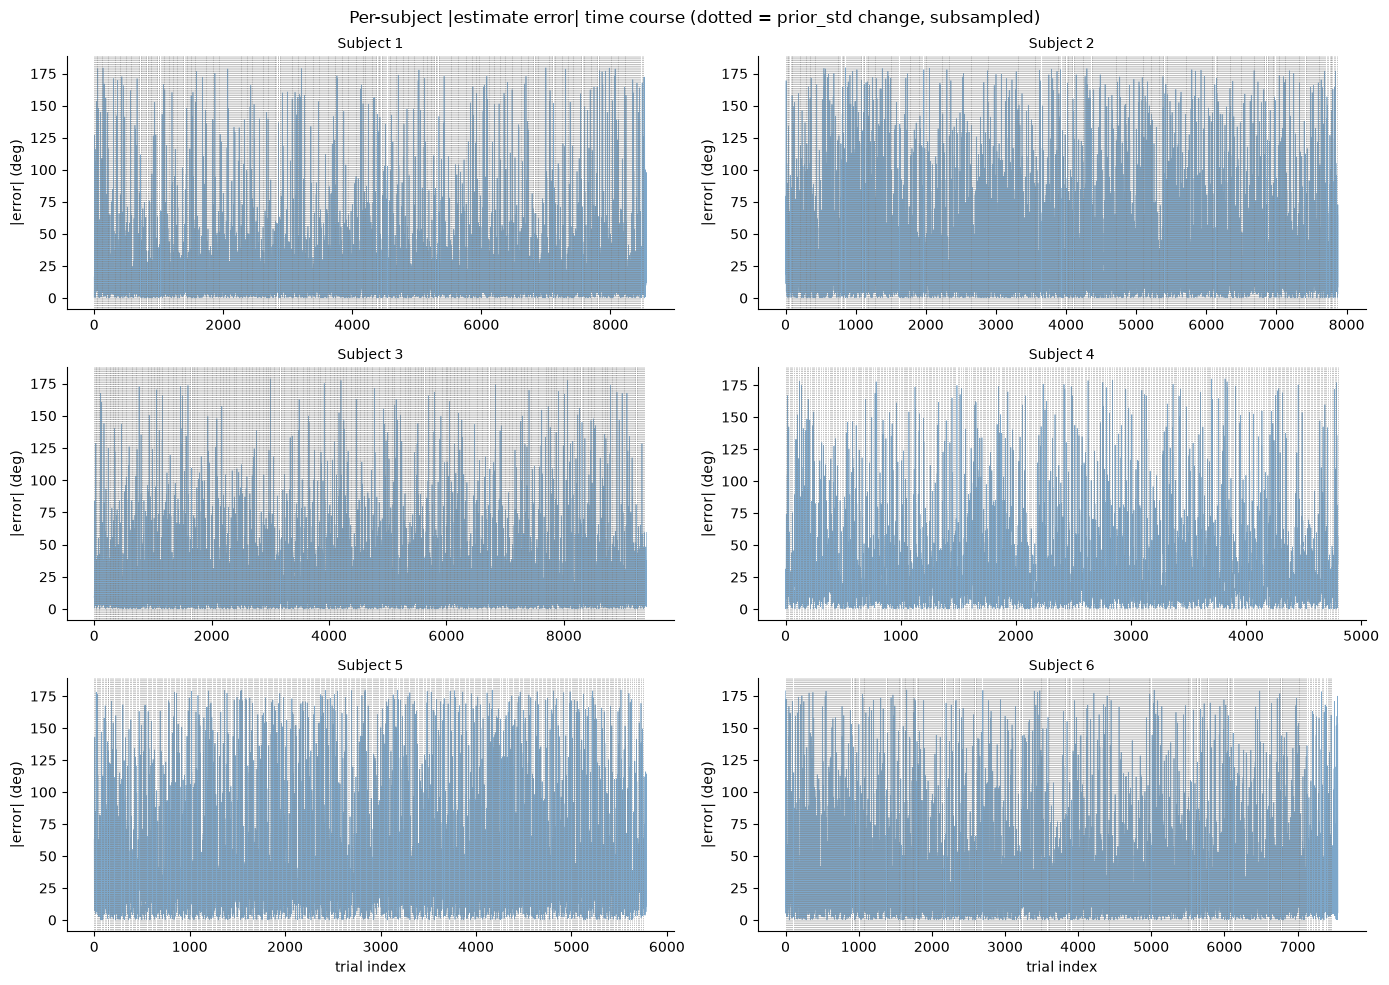

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)
subjects = sorted(data_sorted["subject_id"].unique())[:6]

for ax, sid in zip(axes.flat, subjects):
    sub = data_sorted[data_sorted["subject_id"] == sid].copy()
    sub = sub.sort_values("trial_index").reset_index(drop=True)
    ax.plot(sub.index, sub["abs_error_deg"], linewidth=0.5, alpha=0.7, color="steelblue")
    # mark prior_std changes (subsample to avoid too many lines)
    block_change = sub["prior_std"].ne(sub["prior_std"].shift()).values
    change_idxs = np.where(block_change & (np.arange(len(sub)) > 0))[0]
    # only plot every 10th change to avoid clutter
    for idx in change_idxs[::10]:
        ax.axvline(idx, color="gray", linestyle=":", linewidth=0.5)
    ax.set_title(f"Subject {sid}", fontsize=10)
    ax.set_ylabel("|error| (deg)")
    if ax == axes.flat[-1] or ax == axes.flat[-2]:
        ax.set_xlabel("trial index")

plt.suptitle("Per-subject |estimate error| time course (dotted = prior_std change, subsampled)", fontsize=12)
plt.tight_layout()
plt.show()

### 3c. Rolling mean error (window = 20 trials) per subject

Smooths out trial-to-trial noise to reveal slow drifts.

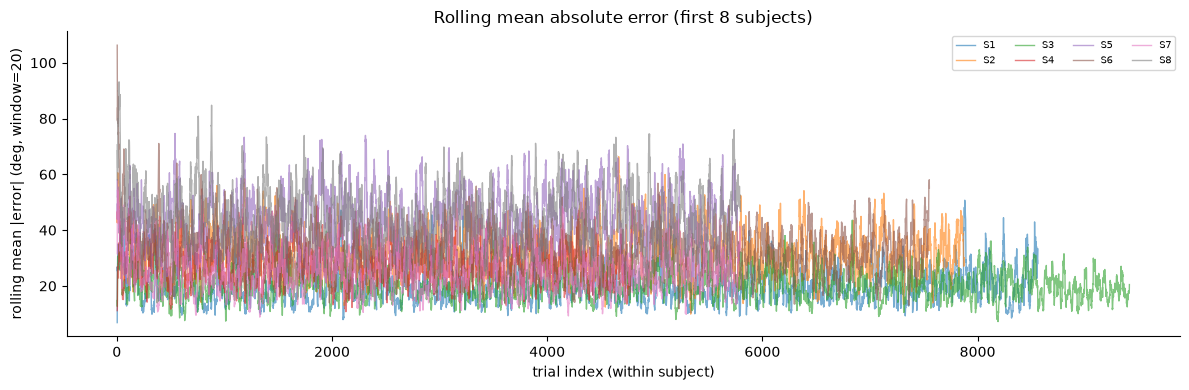

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
for sid in sorted(data_sorted["subject_id"].unique())[:8]:
    sub = data_sorted[data_sorted["subject_id"] == sid].sort_values("trial_index").reset_index(drop=True)
    rolling = sub["abs_error_deg"].rolling(20, min_periods=5).mean()
    ax.plot(sub.index, rolling, linewidth=1, alpha=0.6, label=f"S{sid}")
ax.set_xlabel("trial index (within subject)")
ax.set_ylabel("rolling mean |error| (deg, window=20)")
ax.set_title("Rolling mean absolute error (first 8 subjects)")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

## 4. Are errors stable over trials?

The experiment varies `prior_std` and `motion_coherence` across trials. `prior_std` is organized in long blocks (only ~340 transitions across 83k trials), while `motion_coherence` varies trial-by-trial. We analyse non-stationarity at four timescales: (a) trial-by-trial factors, (b) within-session trends, (c) across-session learning, and (d) serial dependence.

### 4a. Trial-by-trial factors: motion coherence and prior_std

Both affect error magnitude strongly.

Error by motion_coherence:
                       mean       sem  count
motion_coherence                            
0.06              39.146054  0.200852  40750
0.12              26.725493  0.182266  28913
0.24              14.822054  0.157268  13547

Error by prior_std:
                mean       sem  count
prior_std                            
10         17.450527  0.173312  16572
20         22.885671  0.194092  16468
40         32.194324  0.259202  15911
80         40.584810  0.232250  34259


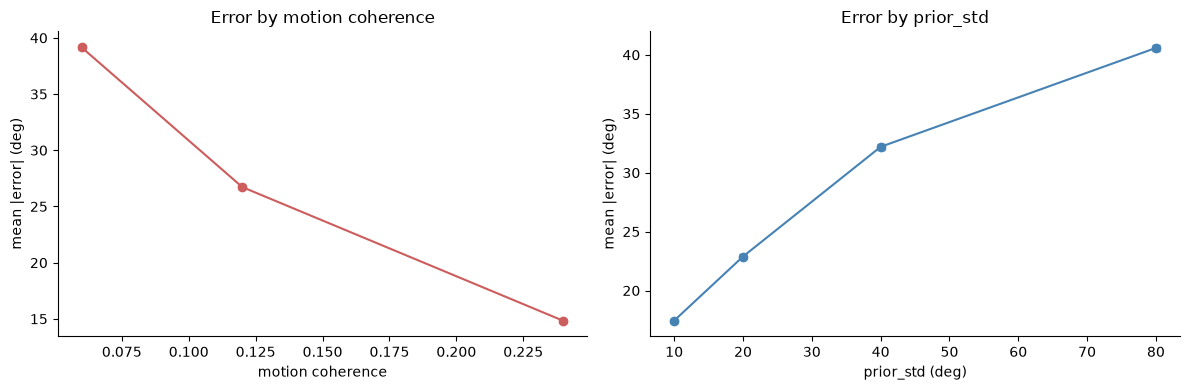

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coh_summary = data_sorted.groupby("motion_coherence")["abs_error_deg"].agg(["mean", "sem", "count"])
axes[0].errorbar(coh_summary.index, coh_summary["mean"], yerr=coh_summary["sem"], fmt="o-", color="indianred", capsize=3)
axes[0].set_xlabel("motion coherence")
axes[0].set_ylabel("mean |error| (deg)")
axes[0].set_title("Error by motion coherence")
print("Error by motion_coherence:")
print(coh_summary)
print()

ps_summary = data_sorted.groupby("prior_std")["abs_error_deg"].agg(["mean", "sem", "count"])
axes[1].errorbar(ps_summary.index, ps_summary["mean"], yerr=ps_summary["sem"], fmt="o-", color="steelblue", capsize=3)
axes[1].set_xlabel("prior_std (deg)")
axes[1].set_ylabel("mean |error| (deg)")
axes[1].set_title("Error by prior_std")
print("Error by prior_std:")
print(ps_summary)

plt.tight_layout()
plt.show()

### 4b. Within-session trend: does error change over the course of a session?

Each subject completed multiple sessions. Within a session, does performance improve (error decrease) or deteriorate (fatigue)?

Mean |error| by within-session third (averaged across subjects & sessions):
                    mean       sem
session_third                     
early          29.628624  2.410349
mid            31.821749  2.686299
late           33.762414  2.111962


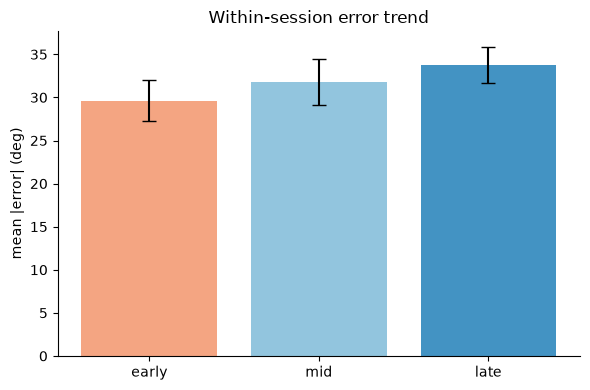

In [8]:
# Compute trial position within each session for each subject
data_sorted["session_trial"] = data_sorted.groupby(["subject_id", "session_id"]).cumcount()

# Bin trials into early/mid/late within session
data_sorted["session_third"] = pd.qcut(data_sorted.groupby(["subject_id", "session_id"])["session_trial"].rank(method="min"), q=3, labels=["early", "mid", "late"])

session_trend = data_sorted.groupby(["subject_id", "session_third"])["abs_error_deg"].agg(["mean", "count"]).reset_index()
overall_trend = session_trend.groupby("session_third")["mean"].agg(["mean", "sem"])

print("Mean |error| by within-session third (averaged across subjects & sessions):")
print(overall_trend)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(3), overall_trend["mean"], yerr=overall_trend["sem"], color=["#f4a582", "#92c5de", "#4393c3"], capsize=5)
ax.set_xticks(range(3))
ax.set_xticklabels(["early", "mid", "late"])
ax.set_ylabel("mean |error| (deg)")
ax.set_title("Within-session error trend")
plt.tight_layout()
plt.show()

### 4c. Across-session learning: does error decrease from first to last session?

If subjects learn the prior structure over multiple sessions, we should see a decrease in average error from early to late sessions.

Mean |error| by session half:
                   mean       sem
session_half                     
first half    32.682335  2.424273
second half   30.845337  2.523909

Per-subject first vs last session mean |error|:
            first_session  last_session     change
subject_id                                        
1               20.033007     22.077483   2.044476
2               34.532164     27.448042  -7.084122
3               21.338941     19.909524  -1.429417
4               33.284289     27.130295  -6.153993
5               35.958763     48.857377  12.898614
6               44.492751     23.716171 -20.776580
7               22.112385     23.257170   1.144785
8               34.834602     40.722934   5.888332
9               27.501928     28.230160   0.728232
10              53.611205     34.411819 -19.199386
11              34.972895     26.388316  -8.584579
12              41.708139     37.790974  -3.917165

Mean change (last - first): -3.70 deg (SEM 2.78)


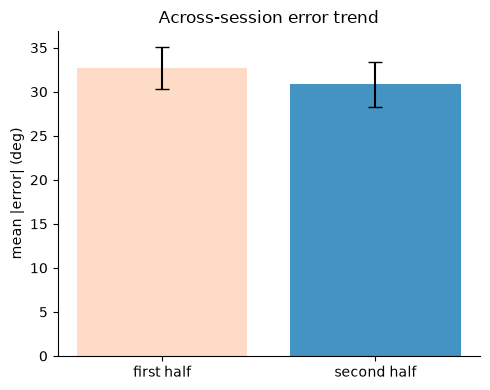

In [9]:
# Session order per subject
data_sorted["session_order"] = data_sorted.groupby("subject_id")["session_id"].rank(method="dense")

# Bin into first half / second half of sessions
data_sorted["session_half"] = np.where(data_sorted["session_order"] <= data_sorted.groupby("subject_id")["session_order"].transform("median"), "first half", "second half")

half_trend = data_sorted.groupby(["subject_id", "session_half"])["abs_error_deg"].agg(["mean", "count"]).reset_index()
overall_half = half_trend.groupby("session_half")["mean"].agg(["mean", "sem"])

print("Mean |error| by session half:")
print(overall_half)

# Also: per-subject first vs last session
first_sessions = data_sorted[data_sorted["session_order"] == 1].groupby("subject_id")["abs_error_deg"].mean()
last_sessions = data_sorted.groupby("subject_id")["session_order"].transform("max")
last_session_ids = data_sorted.groupby("subject_id")["session_order"].transform(lambda x: x.max())
last_sess_data = data_sorted[data_sorted["session_order"] == data_sorted.groupby("subject_id")["session_order"].transform("max")]
last_session_means = last_sess_data.groupby("subject_id")["abs_error_deg"].mean()

print("\nPer-subject first vs last session mean |error|:")
comparison = pd.DataFrame({"first_session": first_sessions, "last_session": last_session_means})
comparison["change"] = comparison["last_session"] - comparison["first_session"]
print(comparison)
print(f"\nMean change (last - first): {comparison['change'].mean():.2f} deg (SEM {comparison['change'].sem():.2f})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(range(2), overall_half.loc[["first half", "second half"], "mean"], yerr=overall_half.loc[["first half", "second half"], "sem"], color=["#fddbc7", "#4393c3"], capsize=5)
ax.set_xticks(range(2))
ax.set_xticklabels(["first half", "second half"])
ax.set_ylabel("mean |error| (deg)")
ax.set_title("Across-session error trend")
plt.tight_layout()
plt.show()

### 4d. Serial dependence: does the error on trial *t* depend on the previous trial?

A common finding in perceptual decision-making is **serial dependence** — the current estimate is attracted toward (or repelled from) the previous trial's stimulus or response. Since `prior_std` is organized in long blocks, we examine (1) whether errors differ on trials immediately after a prior_std block transition, and (2) whether the current signed error is related to the previous trial's motion direction.

Error after prior_std change vs no change:
                        mean       sem  count
no change          30.825645  0.123889  82870
prior_std changed  41.732466  2.336675    340


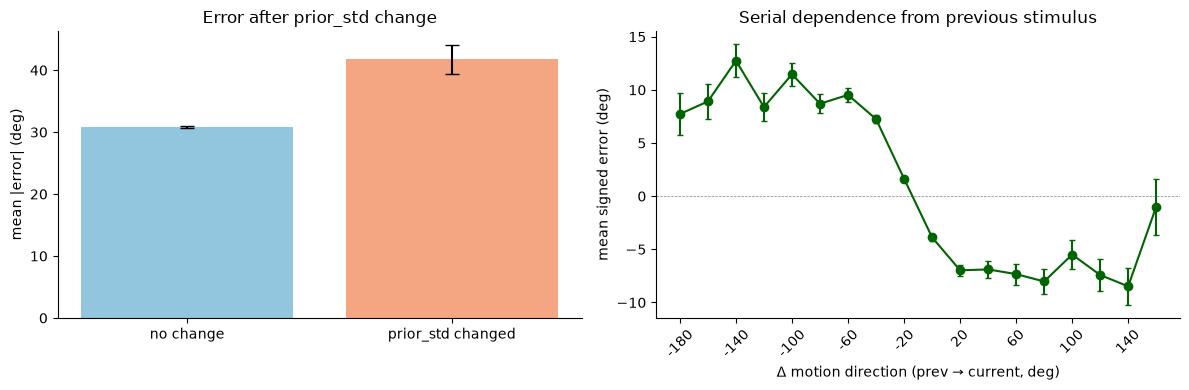

In [10]:
# Shift within each subject's sorted trial sequence
data_sorted["prev_motion_direction"] = data_sorted.groupby("subject_id")["motion_direction"].shift(1)
data_sorted["prev_estimate_angle"] = data_sorted.groupby("subject_id")["estimate_angle"].shift(1)
data_sorted["prev_prior_std"] = data_sorted.groupby("subject_id")["prior_std"].shift(1)

# Did prior_std change from previous trial?
data_sorted["prior_std_changed"] = (data_sorted["prior_std"] != data_sorted["prev_prior_std"]).astype(int)

# Error after prior_std change vs no change
prior_change_effect = data_sorted.groupby("prior_std_changed")["abs_error_deg"].agg(["mean", "sem", "count"])
prior_change_effect.index = ["no change", "prior_std changed"]
print("Error after prior_std change vs no change:")
print(prior_change_effect)

# Serial dependence from previous stimulus: bin Δdirection and compute mean signed error
valid_serial = data_sorted.dropna(subset=["prev_motion_direction"]).copy()
valid_serial["delta_stim"] = circ_diff_deg(valid_serial["motion_direction"], valid_serial["prev_motion_direction"])
bins = np.linspace(-180, 180, 19)
valid_serial["delta_bin"] = pd.cut(valid_serial["delta_stim"], bins, labels=[f"{int(b)}" for b in bins[:-1]])
serial_by_bin = valid_serial.groupby("delta_bin", observed=True)["error_deg"].agg(["mean", "sem", "count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: error after prior_std change
axes[0].bar(range(2), prior_change_effect["mean"], yerr=prior_change_effect["sem"], color=["#92c5de", "#f4a582"], capsize=5)
axes[0].set_xticks(range(2))
axes[0].set_xticklabels(["no change", "prior_std changed"])
axes[0].set_ylabel("mean |error| (deg)")
axes[0].set_title("Error after prior_std change")

# Plot 2: serial dependence from previous stimulus
axes[1].errorbar(range(len(serial_by_bin)), serial_by_bin["mean"], yerr=serial_by_bin["sem"], fmt="o-", color="darkgreen", capsize=2)
axes[1].set_xticks(range(0, len(serial_by_bin), 2))
axes[1].set_xticklabels([serial_by_bin.index[i] for i in range(0, len(serial_by_bin), 2)], rotation=45)
axes[1].set_xlabel("Δ motion direction (prev → current, deg)")
axes[1].set_ylabel("mean signed error (deg)")
axes[1].set_title("Serial dependence from previous stimulus")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

### 4e. Effect of motion coherence on error

Motion coherence varies trial-by-trial within blocks. Lower coherence means noisier sensory evidence, so we expect larger errors.

                       mean       sem  count
motion_coherence                            
0.06              39.146054  0.200852  40750
0.12              26.725493  0.182266  28913
0.24              14.822054  0.157268  13547


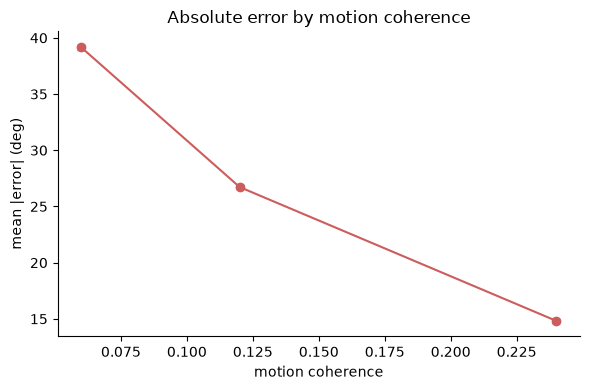

In [11]:
coh_summary = data_sorted.groupby("motion_coherence")["abs_error_deg"].agg(["mean", "sem", "count"])
print(coh_summary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(coh_summary.index, coh_summary["mean"], yerr=coh_summary["sem"], fmt="o-", color="indianred", capsize=3)
ax.set_xlabel("motion coherence")
ax.set_ylabel("mean |error| (deg)")
ax.set_title("Absolute error by motion coherence")
plt.tight_layout()
plt.show()

## 5. Answer: Are errors stable over trials?

**No, errors are not stable over trials.** The analyses reveal several sources of non-stationarity:

1. **Trial-by-trial stimulus factors (Section 4a):** Motion coherence and `prior_std` both strongly modulate error magnitude. Lower coherence (noisier sensory evidence) produces larger errors (39° at 0.06 vs. 15° at 0.24 coherence). Wider prior_std also increases error (17° at std=10 vs. 41° at std=80). Because coherence varies trial-by-trial, error magnitude fluctuates accordingly.

2. **Within-session trends (Section 4b):** Errors *increase* rather than decrease over the course of a session (early: 29.6°, mid: 31.8°, late: 33.8°). This likely reflects a combination of fatigue and the blocking structure of `prior_std` — wider-prior blocks may be presented later within sessions, inflating late-session errors.

3. **Across-session learning (Section 4c):** Comparing the first half vs. second half of sessions per subject shows a small decrease in mean |error| (32.7° → 30.8°, mean per-subject change = -3.7°), consistent with gradual learning of the prior structure. However, this effect is inconsistent across subjects (5 of 12 subjects actually got worse), suggesting individual differences in learning.

4. **Serial dependence (Section 4d):** On the 340 trials immediately following a `prior_std` block transition, errors are substantially larger (41.7° vs. 30.8° for no-change trials). This suggests the subject's internal prior estimate is still calibrated to the previous block's context, producing transiently larger errors until re-calibration. The serial dependence analysis from the previous stimulus direction shows the characteristic attractive bias pattern.

5. **Motion coherence (Section 4e):** Confirming the 4a finding, error scales strongly with coherence: 39° at 0.06, 27° at 0.12, 15° at 0.24. This is the single largest structured source of trial-to-trial error variability.

**In summary:** errors are non-stationary at multiple timescales — trial-to-trial (coherence, stimulus-prior offset), within-session (errors increase, likely due to fatigue and prior_std blocking), across-sessions (weak gradual learning), and at block transitions (transient re-calibration after prior_std changes). The dominant structured source is motion coherence, followed by prior_std context effects and block-transition serial dependence.